In [1]:
# IMPORTS
import torch
import torch.nn as nn
from Binn import BINN
import data_handling as dh
import binn_training as bt
import custom_train_test_split as ctts

# Supress warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# GLOBALS
ALL_CELLTYPES = [0,1,2,3,4,5,6,7,8]
TRAIN_SIZE = 0.8
BATCH_SIZE = 16
MASK_PATHS = [f"/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_{i}_mask.csv" 
              for i in range(5)]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = "/data/shared/alzgene26/data"
data_path = base_path + "/processed_data/completed/full_pipeline/mg_200_mc_200_mhvg1000/"
danish_path = base_path + "/processed_data/danish/"

In [3]:
MASK_PATHS

['/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_0_mask.csv',
 '/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_1_mask.csv',
 '/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_2_mask.csv',
 '/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_3_mask.csv',
 '/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_4_mask.csv']

In [4]:
print("Reading processed adata...")
datasets = ctts.read_files(to_include=ALL_CELLTYPES, filepath=data_path)

Reading processed adata...
Labels to include: ['astro', 'exc1', 'exc2', 'exc3', 'immune', 'inhi', 'oligo', 'opcs', 'vasc']
Reading astro
Reading exc1
Reading exc2
Reading exc3
Reading immune
Reading inhi
Reading oligo
Reading opcs
Reading vasc


In [5]:
datasets

{'astro': AnnData object with n_obs × n_vars = 1235 × 1000
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     layers: 'sum',
 'exc1': AnnData object with n_obs × n_vars = 427 × 1000
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     layers: 'sum',
 'exc2': AnnData object with n_obs × n_vars = 1679 × 1000
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     layers: 'sum',
 'exc3': AnnData object with n_obs × n_vars = 3703 × 1000
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     layers: 'sum',
 'immune': AnnData object with n_obs × n_vars = 1694 × 1000
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     lay

In [6]:
masks = dh.read_masks(MASK_PATHS, print_shapes=True)

Matrix 0 shape: (945, 791)
Matrix 1 shape: (791, 446)
Matrix 2 shape: (446, 168)
Matrix 3 shape: (168, 28)
Matrix 4 shape: (28, 1)


In [7]:
print("Aligning adatas to BINN...")
datasets_aligend = dh.subset_genes(datasets, masks['df0'])

Aligning adatas to BINN...
Overlapping genes kept: 945 for astro
Genes dropped: 55

Overlapping genes kept: 945 for exc1
Genes dropped: 55

Overlapping genes kept: 945 for exc2
Genes dropped: 55

Overlapping genes kept: 945 for exc3
Genes dropped: 55

Overlapping genes kept: 945 for immune
Genes dropped: 55

Overlapping genes kept: 945 for inhi
Genes dropped: 55

Overlapping genes kept: 945 for oligo
Genes dropped: 55

Overlapping genes kept: 945 for opcs
Genes dropped: 55

Overlapping genes kept: 945 for vasc
Genes dropped: 55



In [8]:
print("Padding adatas to BINN-ready shape...")
datasets_padded = dh.pad_align_data(datasets_aligend, masks["df0"])
datasets_padded

Padding adatas to BINN-ready shape...


{'astro': AnnData object with n_obs × n_vars = 1235 × 945
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     layers: 'sum',
 'exc1': AnnData object with n_obs × n_vars = 427 × 945
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     layers: 'sum',
 'exc2': AnnData object with n_obs × n_vars = 1679 × 945
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     layers: 'sum',
 'exc3': AnnData object with n_obs × n_vars = 3703 × 945
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     layers: 'sum',
 'immune': AnnData object with n_obs × n_vars = 1694 × 945
     obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p'
     layers: 

In [9]:
print("Creating AnnCollection...")
acollection = ctts.create_encoded_collection(datasets_padded)
acollection
# NOTE: join_vars="inner" because "outer" would create artificial zeroes in gene expresion???

Creating AnnCollection...


AnnCollection object with n_obs × n_vars = 21221 × 945
  constructed from 9 AnnData objects
    view of layers: 'sum'
    obs: 'subject', 'cell_type_high_res', 'n_obs_aggregated', 'AD_status', 'cell_type_low_res'

In [10]:
print("Creating train/test split...")
train_adata, test_adata = ctts.custom_train_test_split(acollection, train_size=TRAIN_SIZE)

Creating train/test split...
Train Subjects: 341
Test Subjects: 86


In [11]:
print("Getting dataloaders...")
train_loader, test_loader = dh.create_dataloaders(train_adata, test_adata)

Getting dataloaders...


In [12]:
# Extract pure number representation matrices from masks
mask_matrix_list = [masks[mask].to_numpy() for mask in masks]

# Starting amount of features
in_features = masks["df0"].shape[0]

# Extract layer dimensions
layers_list = [masks[mask].shape[1] for mask in masks]

print(f"input features: {in_features}")
print(f"layer list: {layers_list}")

input features: 945
layer list: [791, 446, 168, 28, 1]


In [13]:
# Conversion for mask matrix list, creates tensors for BINN
tensor_masks = [torch.tensor(mask).float() for mask in mask_matrix_list]
# Put on device for BINN
tensor_masks = [mask.to(device) for mask in tensor_masks]

In [14]:
model = BINN(in_features=in_features,
                  layers_list=layers_list,
                  mask_list=tensor_masks).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model

BINN(
  (activation_fn): LeakyReLU(negative_slope=0.1)
  (model_layers): ModuleList(
    (0): Linear(in_features=945, out_features=791, bias=True)
    (1): Linear(in_features=791, out_features=446, bias=True)
    (2): Linear(in_features=446, out_features=168, bias=True)
    (3): Linear(in_features=168, out_features=28, bias=True)
    (4): Linear(in_features=28, out_features=1, bias=True)
  )
  (layer_norms): ModuleList(
    (0): LayerNorm((791,), eps=1e-05, elementwise_affine=True)
    (1): LayerNorm((446,), eps=1e-05, elementwise_affine=True)
    (2): LayerNorm((168,), eps=1e-05, elementwise_affine=True)
    (3): LayerNorm((28,), eps=1e-05, elementwise_affine=True)
  )
)

In [20]:
# Step through the training
EPOCHS = 5
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = bt.train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = bt.test_one_epoch(model, test_loader, criterion, device)
    
    print(f"Epoch {epoch+1} / {EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
    print("-" * 30)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)


Epoch 1 / 5
Train Loss: 0.6894 | Train Acc: 0.4566
Test Loss:  0.6794 | Test Acc:  0.3976
------------------------------
Epoch 2 / 5
Train Loss: 0.6896 | Train Acc: 0.4566
Test Loss:  0.6793 | Test Acc:  0.3976
------------------------------
Epoch 3 / 5
Train Loss: 0.6895 | Train Acc: 0.4566
Test Loss:  0.6765 | Test Acc:  0.3976
------------------------------
Epoch 4 / 5
Train Loss: 0.6895 | Train Acc: 0.4566
Test Loss:  0.6801 | Test Acc:  0.3976
------------------------------
Epoch 5 / 5
Train Loss: 0.6895 | Train Acc: 0.4566
Test Loss:  0.6785 | Test Acc:  0.3976
------------------------------


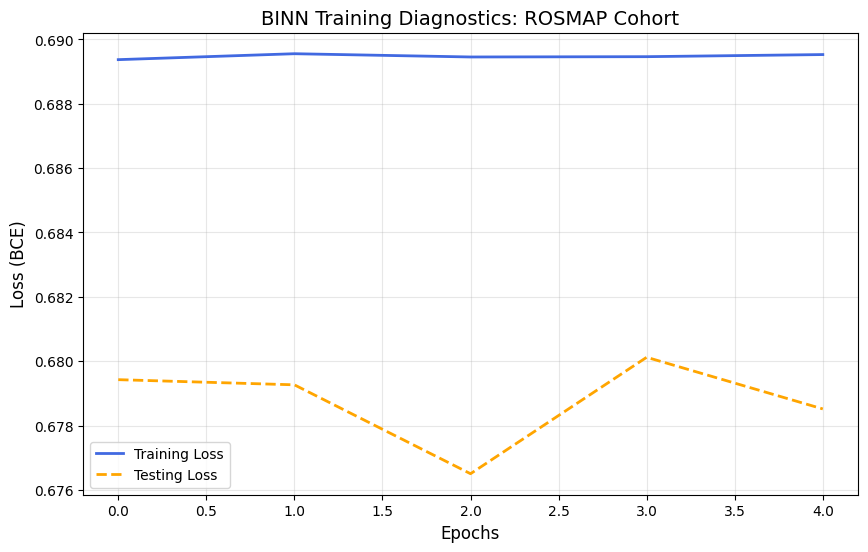

In [21]:
# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Training Loss', color='royalblue', linewidth=2)
plt.plot(history['test_loss'], label='Testing Loss', color='orange', linestyle='--', linewidth=2)

plt.title('BINN Training Diagnostics: ROSMAP Cohort', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (BCE)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()